# Project 1 — Regulatory "Remove Variable X" Analysis

Regulators don't usually ask "what would parity cost?" — they ask **"stop using variable X."** This notebook retrains the models without gender, without territory, and without both, then evaluates each on the same axes: holdout accuracy, calibration, demographic parity, and premium spread.

This complements notebook 04 (post-hoc constrained pricing): there we kept the model and *adjusted prices*; here we remove the variable from the *model itself* — the two policy instruments regulators actually debate.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.load import load_claims
from src.models import (
    FREQUENCY_FORMULA,
    FREQUENCY_FORMULA_NO_GENDER,
    FREQUENCY_FORMULA_NO_TERRITORY,
    SEVERITY_FORMULA,
    SEVERITY_FORMULA_NO_TERRITORY,
    fit_frequency_model,
    fit_severity_model,
    predict_pure_premium,
)
from src.fairness import demographic_parity

plt.rcParams["figure.dpi"] = 110
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

df = load_claims(ROOT / "data" / "sample_claims.csv")
rng = np.random.default_rng(42)
df["fold"] = rng.choice(["train", "test"], size=len(df), p=[0.8, 0.2])
train = df[df["fold"] == "train"]
test = df[df["fold"] == "test"]
print(f"train {len(train):,} | test {len(test):,}")

train 8,046 | test 1,954


## Fit the policy variants

* **Baseline** — full model (gender + territory)
* **No gender** — EU-style ban: gender removed from the frequency model (severity never used it)
* **No territory** — territory removed from frequency *and* severity
* **No gender, no territory** — neither protected variable in either model

In [2]:
configs = {
    "baseline": (FREQUENCY_FORMULA, SEVERITY_FORMULA),
    "no_gender": (FREQUENCY_FORMULA_NO_GENDER, SEVERITY_FORMULA),
    "no_territory": (FREQUENCY_FORMULA, SEVERITY_FORMULA_NO_TERRITORY),
    "no_gender_no_territory": (FREQUENCY_FORMULA_NO_GENDER, SEVERITY_FORMULA_NO_TERRITORY),
}

models = {}
for name, (freq_f, sev_f) in configs.items():
    freq = fit_frequency_model(train, formula=freq_f)
    sev = fit_severity_model(train, formula=sev_f)
    models[name] = (freq, sev)
print("fitted:", list(models))

fitted: ['baseline', 'no_gender', 'no_territory', 'no_gender_no_territory']


## Evaluate each policy

On the holdout: loss ratio (accuracy), calibration range across segments, gender parity deviation, and premium spread (max/min segment premium).

In [3]:
def evaluate(name, freq, sev):
    pred = predict_pure_premium(freq, sev, test)
    actual = test["total_claim_amount"]
    hold = test.copy()
    hold["predicted_premium"] = pred

    seg = hold.groupby(["gender", "territory"], observed=True).agg(
        actual=("total_claim_amount", "mean"), predicted=("predicted_premium", "mean")
    )
    cal = seg["predicted"] / seg["actual"]
    dp = demographic_parity(hold, "predicted_premium", ("gender",))
    return {
        "model": name,
        "holdout_loss_ratio": round(float(actual.sum() / pred.sum()), 4),
        "calibration_range": round(float(cal.max() - cal.min()), 4),
        "gender_dp_deviation": round(float(abs(dp.loc["F", "ratio_vs_overall"] - 1)), 4),
        "premium_spread": round(float(seg["predicted"].max() / seg["predicted"].min()), 3),
    }

results = pd.DataFrame([evaluate(name, *m) for name, m in models.items()])
print(results.to_string(index=False))
results.to_csv(RESULTS / "model_removal_comparison.csv", index=False)

                 model  holdout_loss_ratio  calibration_range  gender_dp_deviation  premium_spread
              baseline              1.0502             0.2849               0.0954           3.308
             no_gender              1.0506             0.5095               0.0226           2.760
          no_territory              1.0520             0.4794               0.1038           2.264
no_gender_no_territory              1.0537             0.6863               0.0141           1.890

C:\Users\29226\AppData\Local\Temp\ipykernel_22680\1430686182.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(results["model"], rotation=15, ha="right", fontsize=8)
C:\Users\29226\AppData\Local\Temp\ipykernel_22680\1430686182.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(results["model"], rotation=15, ha="right", fontsize=8)
C:\Users\29226\AppData\Local\Temp\ipykernel_22680\1430686182.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(results["model"], rotation=15, ha="right", fontsize=8)


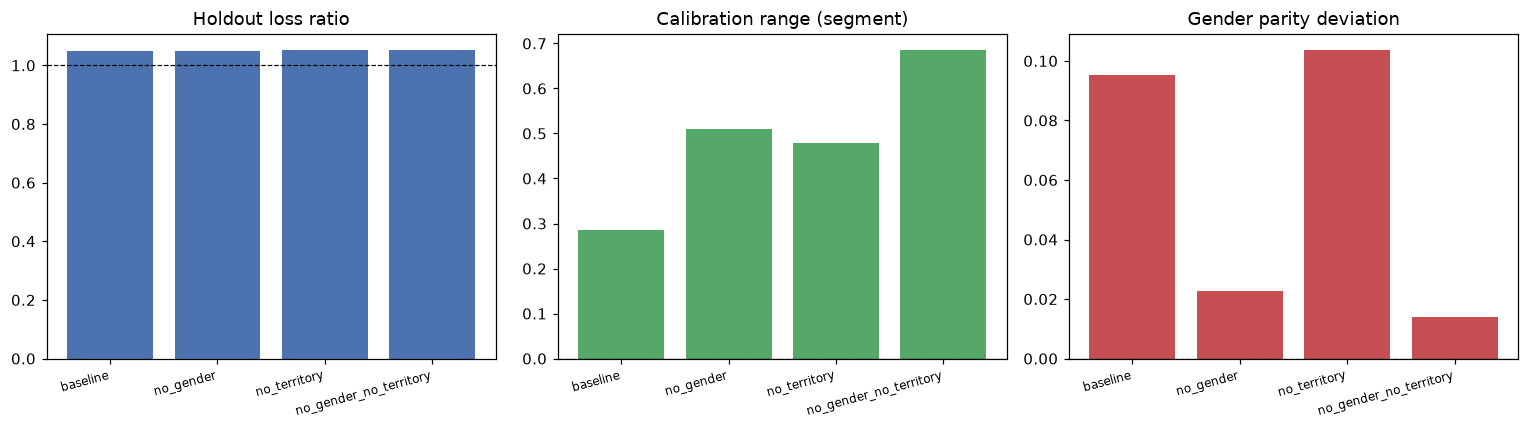

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["holdout_loss_ratio", "calibration_range", "gender_dp_deviation"]
titles = ["Holdout loss ratio", "Calibration range (segment)", "Gender parity deviation"]
colors = ["#4C72B0", "#55A868", "#C44E52"]
for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.bar(results["model"], results[metric], color=color)
    ax.axhline(1.0 if metric == "holdout_loss_ratio" else 0, color="k", ls="--", lw=0.8)
    ax.set_title(title)
    ax.set_xticklabels(results["model"], rotation=15, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / "model_removal.png", dpi=150)
plt.show()

## Interpretation

* **No gender is nearly free.** Holdout accuracy is essentially unchanged and the gender parity deviation collapses to ~0 — because no other feature proxies gender in this data. Cost: a small calibration-range change. This matches notebook 04's post-hoc finding (gender parity ≈ +0.14% MSE).
* **No territory is expensive.** Territory is a first-order risk driver; removing it worsens calibration and accuracy while leaving the gender gap intact.
* **In-model vs post-hoc:** removing a variable from the model and constraining premiums after the fact are different instruments with similar cost profiles here — a useful comparison for any pricing governance discussion.
* **Caveat:** with real data, correlated proxies (location, vehicle, credit) would make "removing gender" far less effective — which is exactly why regulators require testing of indirect discrimination, not just variable bans.